# Exploring decisions
It will help better understand those PDFs and do better chunking and single RAG

## Imports and paths

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pdfplumber # Great for inspecting PDF layout
from pathlib import Path
from tqdm.notebook import tqdm
from unidecode import unidecode
import re
import random
random.seed(42)
from collections import Counter


# style for charts
sns.set_theme(style="whitegrid")

# define project paths based on your structure
BASE_DIR = Path('..') 
RAW_DATA_DIR = BASE_DIR / 'data' / '01_raw_pdfs'

print(f"Looking for data in: {RAW_DATA_DIR.resolve()}")

Looking for data in: /Users/stefanec/STU_FIIT/bachelor-thesis-legal-text-information-extraction/data/01_raw_pdfs


## Definition - Text normalization + regex bank

In [2]:
def norm_pair(raw: str):
    """
    Returns:
      raw_lower: lowercased original (keeps '§')
      ascii_norm: lower + unidecode (diacritics removed; '§' -> 'ss')
    """
    raw = raw or ""
    raw_lower = raw.lower()
    ascii_norm = unidecode(raw_lower)
    ascii_norm = re.sub(r"[ \t]+", " ", ascii_norm)
    return raw_lower, ascii_norm

def spaced_word_regex(word: str) -> str:
    # matches spaced-out headers like "o d o v o d n e n i e"
    return r"\s*".join(map(re.escape, word))

RE_ODOV = re.compile(spaced_word_regex("odovodnenie"), re.IGNORECASE)
RE_POUC = re.compile(spaced_word_regex("poucenie"), re.IGNORECASE)
RE_VYROK = re.compile(r"\b(vyrok|rozhodol|takto\s+rozhodol)\b", re.IGNORECASE)

# IMPORTANT: match both '§' (raw) and 'ss' (unidecode of '§')
PAR = r"(?:§|ss)\s*"

KEY = {
    # core
    "has_penalty": re.compile(r"\bzmluvn\w*\s+pokut\w*\b"),
    "has_301":     re.compile(PAR + r"301\b"),

    # civil noise
    "has_oz_545a": re.compile(PAR + r"545\s*a\b|" + PAR + r"545a\b"),
    "has_oz_544":  re.compile(PAR + r"544\b"),

    # moderation / proportionality signals
    "has_moder_trig": re.compile(r"\b(primeran\w*|neprimeran\w*|moder\w*|zniz\w*|zníz\w*|zníž\w*|neprizna\w*|zamiet\w*)\b"),

    # other grounds (to separate from moderation)
    "has_invalidity": re.compile(r"\b(neplatn\w*|neurcit\w*|neurčit\w*|dobr\w*\s+mrav\w*|poctiv\w*\s+obchodn\w*\s+styk\w*)\b"),

    # interest confusion (rate != penalty)
    "has_interest": re.compile(r"\b(urok\w*|urok\s+z\s+omeskania|omeskan\w*)\b"),

    # candidates
    "has_percent": re.compile(r"(\d+(?:[.,]\d+)?)\s*%"),
    "has_money":   re.compile(r"(\d{1,3}(?:[ \.\u00A0]\d{3})*(?:,\d+)?|\d+(?:,\d+)?)\s*(eur|€|sk|sk\.)"),
}


## Load file registry

In [3]:
records = []


# structure: 01_raw_pdfs / {case_folder} / {file}.pdf
pdf_files = list(RAW_DATA_DIR.rglob("*.pdf"))

print(f"Found {len(pdf_files)} PDF files. Processing metadata...")

for pdf_path in tqdm(pdf_files):
    folder = pdf_path.parent
    
    # JSON: prefer exact match
    meta_path = pdf_path.with_suffix(".json")
    if meta_path.exists():
        json_files = [meta_path]
    else:
        json_files = list(folder.glob("*.json"))
    
    metadata = {}
    if json_files:
        try:
            with open(json_files[0], 'r', encoding='utf-8') as f:
                metadata = json.load(f)
        except Exception as e:
            print(f"Error reading JSON for {pdf_path.name}: {e}")

    # --- EXTRACTING FIELDS BASED ON  JSON STRUCTURE ---
    
    # 1. gett court name (is nested inside 'sud' -> 'nazov')
    court_info = metadata.get('sud', {})
    court_name = court_info.get('nazov', 'Unknown')
    
    # 2. get date (format is dd.mm.yyyy)
    raw_date = metadata.get('datumVydania', None)
    
    # 3. get Case ID (Spisová značka)
    case_id = metadata.get('spisovaZnacka', folder.name)
    
    # 4. get decision type (Rozsudok vs Uznesenie)
    # decision_form normalization
    decision_form = metadata.get('formaRozhodnutia', 'Unknown')
    if isinstance(decision_form, list):
        decision_form = decision_form[0] if decision_form else "Unknown"
    
    # 5. get ECLI (Unique ID)
    ecli = metadata.get('ecli', 'N/A')

    # creating  record
    record = {
        'filename': pdf_path.name,
        'rel_path': str(pdf_path.relative_to(BASE_DIR)),
        'file_size_kb': round(pdf_path.stat().st_size / 1024, 2),
        'court': court_name, 
        'date_str': raw_date, # keeping string for now
        'case_id': case_id,
        'type': decision_form,
        'ecli': ecli,
        'raw_metadata': metadata # storing also full json just to be sure
    }
    records.append(record)

# convert to DataFrame
df = pd.DataFrame(records)

# convert date column to datetime objects ( format dd.mm.yyyy)
# dayfirst=True
df['date'] = pd.to_datetime(df['date_str'], format='%d.%m.%Y', errors='coerce', dayfirst=True)

print(f"Loaded dataframe with {len(df)} rows.")

# show sample
display(df[['case_id', 'court', 'date', 'type']])

Found 176 PDF files. Processing metadata...


  0%|          | 0/176 [00:00<?, ?it/s]

Loaded dataframe with 176 rows.


,case_id,court,date,type
0,35Cbi/59/2006,Krajský súd v Banskej Bystrici,2012-06-04,Rozsudok
1,B5-1CbZm/453/2014,Mestský súd Bratislava III,2018-11-29,Rozsudok
2,6Co/65/2013,Krajský súd v Trenčíne,2013-02-26,Uznesenie
3,31Cob/64/2011,Krajský súd v Trnave,2011-12-20,Rozsudok
4,PN-10Cb/39/2009,Okresný súd Trnava,2011-10-25,Rozsudok
...,...,...,...,...
171,5Cob/11/2022,Krajský súd v Prešove,2022-06-21,Rozsudok
172,B1-14C/79/2011,Mestský súd Bratislava IV,2013-11-29,Uznesenie
173,2Cob/140/2023,Krajský súd v Bratislave,2025-04-15,Rozsudok
174,11Co/20/2018,Krajský súd v Žiline,2018-08-28,Rozsudok


## PDF quality - smoke test

In [4]:
def check_pdf_text_quality(pdf_path):
    """
    Opens a PDF and tries to extract text from the first page.
    Returns the text length and a snippet.
    """
    try:
        with pdfplumber.open(pdf_path) as pdf:
            if not pdf.pages:
                return 0, "EMPTY_FILE"
            
            first_page_text = pdf.pages[0].extract_text()
            if not first_page_text:
                return 0, "NO_TEXT_FOUND (Scanned?)"
            
            return len(first_page_text), first_page_text[:200].replace('\n', ' ')
    except Exception as e:
        return 0, f"Error: {str(e)}"

# applying this check to a sample of 5 documents
sample_df = df.head(10).copy()
print("Inspecting first 10 documents for text content...")

results = []
for _, row in sample_df.iterrows():
    full_path = BASE_DIR / row['rel_path']
    length, snippet = check_pdf_text_quality(full_path)
    results.append({'filename': row['filename'], 'text_len': length, 'snippet': snippet})

pd.DataFrame(results)

Inspecting first 10 documents for text content...


,filename,text_len,snippet
0,KS_Banská_Bystrica_35Cbi_59_2006_00_dokument.pdf,3336,Súd: Krajský súd Banská Bystrica Spisová značk...
1,KS_Bratislava_4CoZm_2_2018_00_dokument.pdf,3271,Súd: Krajský súd Bratislava Spisová značka: 4C...
2,KS_Trenčín_6Co_65_2013_00_dokument.pdf,3557,Súd: Krajský súd Trenčín Spisová značka: 6Co/6...
3,KS_Trnava_31Cob_64_2011_00_dokument.pdf,3119,Súd: Krajský súd Trnava Spisová značka: 31Cob/...
4,KS_Trnava_21Cob_41_2011_00_dokument.pdf,2878,Súd: Krajský súd Trnava Spisová značka: 21Cob/...
5,KS_Nitra_15Cob_70_2022_00_dokument.pdf,3199,Súd: Krajský súd Nitra Spisová značka: 15Cob/7...
6,KS_Žilina_13Cob_7_2017_00_dokument.pdf,3277,Súd: Krajský súd Žilina Spisová značka: 13Cob/...
7,KS_Prešov_1Cob_20_2012_00_dokument.pdf,3103,Súd: Krajský súd Prešov Spisová značka: 1Cob/2...
8,KS_Bratislava_1Cob_117_2020_00_dokument.pdf,2757,Súd: Krajský súd Bratislava Spisová značka: 1C...
9,KS_Nitra_26Cob_39_2012_00_dokument.pdf,3057,Súd: Krajský súd Nitra Spisová značka: 26Cob/3...


## Text statistics

In [5]:
# 1.4b EDA Feature Extraction Pass (ONE PASS) - FIXED


def extract_full_text(pdf) -> str:
    # keep newlines -> paragraphs and sections
    return "\n\n".join([(p.extract_text() or "") for p in pdf.pages])

rows = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    path = BASE_DIR / row["rel_path"]
    out = {"rel_path": row["rel_path"]}  # safer key than filename

    try:
        with pdfplumber.open(path) as pdf:
            out["page_count"] = len(pdf.pages)

            t = extract_full_text(pdf)
            out["char_count"] = len(t)
            out["est_tokens"] = int(out["char_count"] / 4)

            raw_lower, ascii_norm = norm_pair(t)

            # counts (use ascii_norm -> diacritics-safe + '§' handled via (?:§|ss))
            for k, rx in KEY.items():
                out[k] = len(rx.findall(ascii_norm))

            # sections (robust)
            out["has_odovodnenie"] = int(bool(RE_ODOV.search(ascii_norm)))
            out["has_poucenie"] = int(bool(RE_POUC.search(ascii_norm)))
            out["has_vyrok"] = int(bool(RE_VYROK.search(ascii_norm)))

            # paragraph stats (chunk readiness)
            pars = [p.strip() for p in re.split(r"\n\s*\n", t) if p.strip()]
            par_lens = [int(len(p)/4) for p in pars]  # token-ish
            out["n_pars"] = len(pars)
            out["par_max_tokens"] = max(par_lens) if par_lens else 0
            out["par_p90_tokens"] = int(np.percentile(par_lens, 90)) if len(par_lens) >= 2 else (par_lens[0] if par_lens else 0)

    except Exception as e:
        out["page_count"] = 0
        out["char_count"] = 0
        out["est_tokens"] = 0
        out["error"] = str(e)

    rows.append(out)

df_feat = pd.DataFrame(rows)

# drop old feature cols if rerun
feature_cols = [c for c in df_feat.columns if c != "rel_path"]
df = df.drop(columns=[c for c in feature_cols if c in df.columns], errors="ignore")

df = df.merge(df_feat, on="rel_path", how="left")

df[["page_count","char_count","est_tokens","has_penalty","has_301","has_oz_545a","has_oz_544"]].head()


  0%|          | 0/176 [00:00<?, ?it/s]

,page_count,char_count,est_tokens,has_penalty,has_301,has_oz_545a,has_oz_544
0,6,23517,5879,48,0,0,0
1,10,44468,11117,15,0,0,0
2,3,11916,2979,1,0,0,0
3,4,11461,2865,9,0,0,0
4,4,16167,4041,26,0,0,0


## Header / footer repetitions

In [6]:


def page_edge_lines(pdf_path: Path, n_lines=2, max_pages=10):
    top, bottom = [], []
    with pdfplumber.open(pdf_path) as pdf:
        for pg in pdf.pages[:max_pages]:
            t = (pg.extract_text() or "").strip()
            lines = [x.strip() for x in t.splitlines() if x.strip()]
            top.extend(lines[:n_lines])
            bottom.extend(lines[-n_lines:])
    return top, bottom

top_c = Counter()
bot_c = Counter()

sample_paths = df.sample(min(30, len(df)), random_state=42)["rel_path"].tolist()
for rp in sample_paths:
    p = BASE_DIR / rp
    t, b = page_edge_lines(p, n_lines=2, max_pages=10)
    top_c.update(t); bot_c.update(b)

top_df = pd.DataFrame(top_c.most_common(30), columns=["line","count"])
bot_df = pd.DataFrame(bot_c.most_common(30), columns=["line","count"])

display(top_df.head(15))
display(bot_df.head(15))


,line,count
0,Súd: Krajský súd Bratislava,11
1,Súd: Krajský súd Košice,4
2,Súd: Krajský súd Trenčín,4
3,Súd: Najvyšší súd,4
4,Poučenie:,3
5,Súd: Krajský súd Banská Bystrica,2
6,Proti tomuto rozhodnutiu odvolanie nie je príp...,2
7,V dovolaní sa popri všeobecných náležitostiach...,2
8,"akom rozsahu sa toto rozhodnutie napáda, z aký...",2
9,Proti rozhodnutiu odvolacieho súdu je prípustn...,2


,line,count
0,Poučenie:,16
1,"akom rozsahu sa toto rozhodnutie napáda, z aký...",8
2,Proti tomuto rozsudku odvolanie nie je prípustné.,6
3,(dovolacie dôvody) a čoho sa dovolateľ domáha ...,5
4,Proti tomuto uzneseniu odvolanie nie je prípus...,4
5,"24ZSS9102395000A,",2
6,"rozhodnutiu smeruje, v akom rozsahu sa toto ro...",2
7,považuje za nesprávne (dovolacie dôvody) a čoh...,2
8,(dovolacie dôvody) a čoho sa dovolateľ domáha ...,2
9,Proti tomuto uzneseniu nie je prípustný opravn...,2


## Visualizing the Dataset

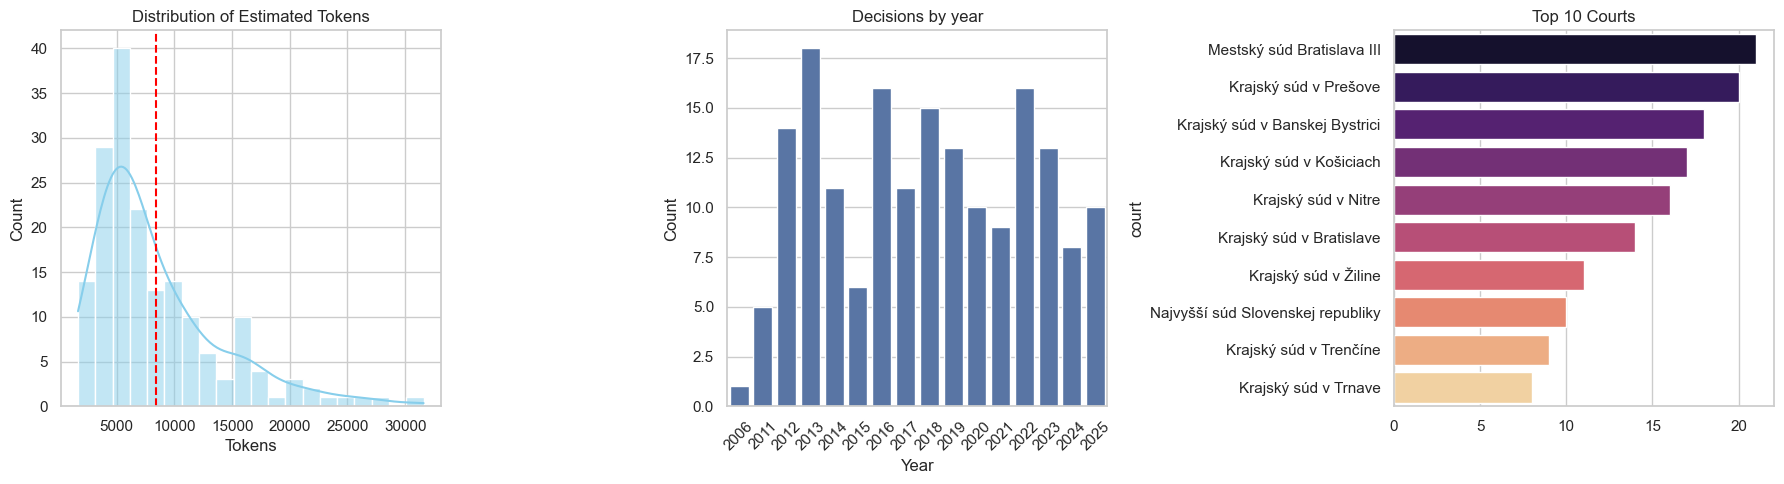

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of tokens (how expensive will the LLM be?)
sns.histplot(df['est_tokens'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Estimated Tokens')
axes[0].set_xlabel('Tokens')
axes[0].axvline(df['est_tokens'].mean(), color='red', linestyle='--', label='Mean')

# 2. distribution of years (temporal coverage)
if df['date'].notna().sum() > 0:
    df["year"] = df["date"].dt.year
    year_counts = df["year"].dropna().astype(int).value_counts().sort_index()
    
    sns.barplot(x=year_counts.index.astype(str), y=year_counts.values, ax=axes[1])
    axes[1].set_title("Decisions by year")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Count")

# 3. top courts (Where does data come from?)
top_courts = df['court'].value_counts().head(10)
sns.barplot(
    x=top_courts.values,
    y=top_courts.index,
    hue=top_courts.index,       
    palette='magma',
    ax=axes[2],
    legend=False             
)
axes[2].set_title('Top 10 Courts')

plt.tight_layout()
plt.show()


## Deep Dive into ONE Document

In [8]:
# choose real document from df
sample_row = df.sample(1, random_state=42).iloc[0]
path = BASE_DIR / sample_row['rel_path']

with pdfplumber.open(path) as pdf:
    print(f"Analyzing: {sample_row['filename']}")
    print(f"Total pages: {len(pdf.pages)}")

    p1 = pdf.pages[0]
    text = p1.extract_text() or ""
    print("\n--- PAGE 1 (first 800 chars) ---")
    print(text[:800])

    # fast layout sanity (how much words and their bbox)
    words = p1.extract_words()[:20]
    print("\n--- FIRST 20 WORD BOXES ---")
    for w in words:
        print(w["text"], (w["x0"], w["top"], w["x1"], w["bottom"]))


Analyzing: KS_Bratislava_1Cob_187_2015_00_dokument.pdf
Total pages: 5

--- PAGE 1 (first 800 chars) ---
Súd: Krajský súd Bratislava
Spisová značka: 1Cob/187/2015
Identifikačné číslo súdneho spisu: 1314214384
Dátum vydania rozhodnutia: 06. 10. 2016
Meno a priezvisko sudcu, VSÚ: JUDr. Soňa Pekarčíková
ECLI: ECLI:SK:KSBA:2016:1314214384.1
ROZSUDOK V MENE
SLOVENSKEJ REPUBLIKY
Krajský súd v Bratislave v senáte zloženom z predsedníčky senátu Mgr. Soni Pekarčíkovej a členiek
senátu JUDr. Andrey Haitovej a JUDr. Andrey Sedlačkovej v právnej veci žalobcu: CRIF - Slovak Credit
Bureau, s. r. o., Malý trh 2/A, Bratislava, IČO: 35 886 013, zast.: Advokátska kancelária Kuhajda, s.r.o.,
Karadžičova 47, Bratislava 811 07, proti žalovanému: K. J., F. XXXX/X, R., IČO: XXXXXXXX, o zaplatenie
648,94 eur s príslušenstvom a o odvolaní žalobcu proti rozsudku Okresného súdu Bratislava III č.k.
26Cb/10/2015-52 zo dň

--- FIRST 20 WORD BOXES ---
Súd: (70.866, 74.19600015000003, 91.416, 84.19600015000003)
Krajsk

## Does decisions talk about contractual penalty

In [9]:
print(df["has_301"].gt(0).sum(), "docs mention §301")
print(df["has_penalty"].gt(0).sum(), "docs mention zmluvná pokuta")
print(df["has_oz_545a"].gt(0).sum(), "docs mention OZ §545a")
print(df["has_oz_544"].gt(0).sum(), "docs mention OZ §544")

0 docs mention §301
176 docs mention zmluvná pokuta
0 docs mention OZ §545a
0 docs mention OZ §544


## 1.7b Better categories

In [10]:
# (target = penalty + 301)
def label(row):
    if row["has_oz_545a"] > 0 or row["has_oz_544"] > 0:
        return "CIVIL_NOISE_LIKELY"
    if row["has_penalty"] > 0 and row["has_301"] > 0 and row["has_moder_trig"] > 0 and row["has_invalidity"] == 0:
        return "MODERATION_LIKELY"
    if row["has_penalty"] > 0 and row["has_invalidity"] > 0:
        return "INVALIDITY_OR_OTHER_GROUND_LIKELY"
    if row["has_penalty"] > 0 and row["has_301"] > 0:
        return "PENALTY_AND_301_BUT_UNCLEAR"
    if row["has_penalty"] > 0:
        return "PENALTY_MENTION_NO_301"
    return "IRRELEVANT_LIKELY"

df["eda_label"] = df.apply(label, axis=1)
df["eda_label"].value_counts()


eda_label
INVALIDITY_OR_OTHER_GROUND_LIKELY    138
PENALTY_MENTION_NO_301                38
Name: count, dtype: int64

## 1.8 Structural integrity check (the "section splitter" test)

In [11]:

print("Odôvodnenie coverage:", (df["has_odovodnenie"] == 1).mean())
print("Poučenie coverage:", (df["has_poucenie"] == 1).mean())
print("Výrok coverage:", (df["has_vyrok"] == 1).mean())

# show the worst cases ( a littbe bit of text or damaged layout)
df.sort_values(["has_odovodnenie","char_count"]).head(20)[
    ["filename","court","case_id","page_count","char_count","has_odovodnenie","has_poucenie","has_vyrok","eda_label"]
]


Odôvodnenie coverage: 1.0
Poučenie coverage: 1.0
Výrok coverage: 0.9715909090909091


,filename,court,case_id,page_count,char_count,has_odovodnenie,has_poucenie,has_vyrok,eda_label
68,KS_Nitra_15Cob_16_2012_00_dokument.pdf,Krajský súd v Nitre,15Cob/16/2012,3,6617,1,1,1,PENALTY_MENTION_NO_301
121,KS_Nitra_26CoKR_5_2016_00_dokument.pdf,Krajský súd v Nitre,26CoKR/5/2016,2,6638,1,1,1,PENALTY_MENTION_NO_301
78,KS_Nitra_26Cob_69_2014_00_dokument.pdf,Krajský súd v Nitre,26Cob/69/2014,3,6699,1,1,1,PENALTY_MENTION_NO_301
15,KS_Trenčín_8Cob_82_2011_00_dokument.pdf,Okresný súd Prievidza,BN-5Cb/26/2010,3,9128,1,1,1,INVALIDITY_OR_OTHER_GROUND_LIKELY
169,KS_Trenčín_8Cob_74_2011_00_dokument.pdf,Okresný súd Prievidza,BN-3Cb/38/2010,3,9507,1,1,1,INVALIDITY_OR_OTHER_GROUND_LIKELY
102,KS_Trenčín_8Cob_64_2011_00_dokument.pdf,Okresný súd Prievidza,BN-3Cb/27/2010,3,10040,1,1,1,INVALIDITY_OR_OTHER_GROUND_LIKELY
142,KS_Bratislava_2Cob_344_2016_00_dokument.pdf,Mestský súd Bratislava III,B1-31Cb/166/2013,3,10713,1,1,1,PENALTY_MENTION_NO_301
161,KS_Bratislava_3Cob_387_2013_00_dokument.pdf,Krajský súd v Bratislave,3Cob/387/2013,3,10846,1,1,1,INVALIDITY_OR_OTHER_GROUND_LIKELY
3,KS_Trnava_31Cob_64_2011_00_dokument.pdf,Krajský súd v Trnave,31Cob/64/2011,4,11461,1,1,1,INVALIDITY_OR_OTHER_GROUND_LIKELY
61,KS_Trenčín_8Cob_38_2012_00_dokument.pdf,Okresný súd Prievidza,BN-5Cb/22/2010,4,11791,1,1,1,PENALTY_MENTION_NO_301


## Chunk readiness: paragraph and long paragraphs

       n_pars  par_p90_tokens  par_max_tokens
count   176.0           176.0           176.0
mean      7.9          1256.1          1289.6
std       4.4           113.0           112.0
min       2.0           871.0           899.0
25%       5.0          1210.0          1245.8
50%       6.5          1280.5          1320.0
75%      10.0          1336.5          1367.5
max      26.0          1407.0          1450.0
Docs needing token-fallback (par_max_tokens>1000): 0.966


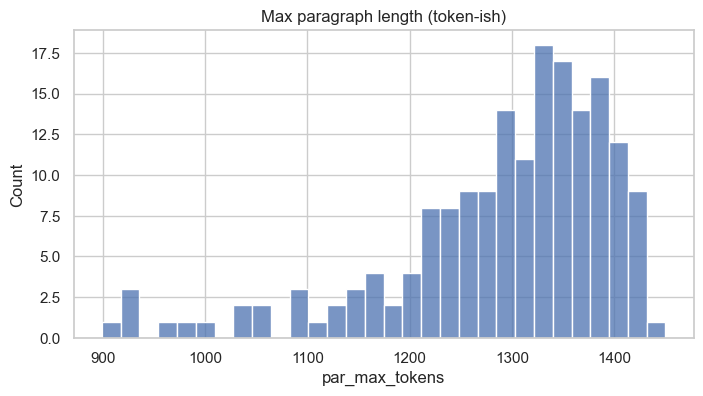

In [12]:
print(df[["n_pars","par_p90_tokens","par_max_tokens"]].describe().round(1))

# how much documents will need token fallback? (> 1000 tokens per paragraph)
fallback_rate = (df["par_max_tokens"] > 1000).mean()
print("Docs needing token-fallback (par_max_tokens>1000):", round(fallback_rate, 3))

plt.figure(figsize=(8,4))
sns.histplot(df["par_max_tokens"], bins=30)
plt.title("Max paragraph length (token-ish)")
plt.show()


## Interest vs penalty confusion

In [13]:
# if document has percentage and interest trig, it is risky
df["interest_risk"] = (df["has_percent"] > 0) & (df["has_interest"] > 0)

print("Docs with % and interest language:", df["interest_risk"].mean())

#  MODERATION_LIKELY vs others
pd.crosstab(df["eda_label"], df["interest_risk"], normalize="index")


Docs with % and interest language: 0.9034090909090909


interest_risk,False,True
eda_label,,
INVALIDITY_OR_OTHER_GROUND_LIKELY,0.079710,0.920290
PENALTY_MENTION_NO_301,0.157895,0.842105


## Manual audit

In [14]:
OUT = BASE_DIR / "data" / "eda_outputs"
OUT.mkdir(parents=True, exist_ok=True)

def stratified_sample(df_, n=10):
    out = []
    for label, g in df_.groupby("eda_label"):
        out.append(g.sample(min(n, len(g)), random_state=42))
    return pd.concat(out).sample(frac=1, random_state=42)

audit = stratified_sample(df, n=8)[
    ["filename","rel_path","court","case_id","date","type","eda_label",
     "has_penalty","has_301","has_moder_trig","has_invalidity","has_interest",
     "page_count","char_count"]
].copy()

audit["MAN_really_moderation"] = ""
audit["MAN_is_commercial"] = ""
audit["MAN_outcome"] = ""  # reduced / upheld / denied / unclear

audit.to_csv(OUT/"manual_audit_sample.csv", index=False)
audit.head()


,filename,rel_path,court,case_id,date,type,eda_label,has_penalty,has_301,has_moder_trig,has_invalidity,has_interest,page_count,char_count,MAN_really_moderation,MAN_is_commercial,MAN_outcome
113,KS_Trenčín_8Cob_112_2021_00_dokument.pdf,data/01_raw_pdfs/8Cob_112_2021/KS_Trenčín_8Cob...,Krajský súd v Trenčíne,8Cob/112/2021,2022-06-22,Rozsudok,INVALIDITY_OR_OTHER_GROUND_LIKELY,75,0,56,10,35,15,66361,,,
131,KS_Bratislava_2Cob_186_2017_00_dokument.pdf,data/01_raw_pdfs/2Cob_186_2017/KS_Bratislava_2...,Mestský súd Bratislava III,B2-22Cb/442/2015,2018-07-10,Uznesenie,INVALIDITY_OR_OTHER_GROUND_LIKELY,47,0,8,8,38,10,40385,,,
86,KS_Bratislava_5Co_246_2014_00_dokument.pdf,data/01_raw_pdfs/5Co_246_2014/KS_Bratislava_5C...,Mestský súd Bratislava IV,B1-18Ro/74/2011,2015-03-31,Rozsudok,INVALIDITY_OR_OTHER_GROUND_LIKELY,26,0,18,1,7,6,23705,,,
44,KS_Košice_3Cob_224_2014_00_dokument.pdf,data/01_raw_pdfs/3Cob_224_2014/KS_Košice_3Cob_...,Krajský súd v Košiciach,3Cob/224/2014,2015-08-31,Rozsudok,PENALTY_MENTION_NO_301,73,0,37,0,30,7,24938,,,
133,KS_Košice_4Cob_35_2023_00_dokument.pdf,data/01_raw_pdfs/4Cob_35_2023/KS_Košice_4Cob_3...,Krajský súd v Košiciach,4Cob/35/2023,2023-08-08,Rozsudok,PENALTY_MENTION_NO_301,59,0,4,0,28,7,28478,,,
